# Visualisation des masks de segmentation — OC26

Comparaison **TensorFlow / Mesmer** vs **ONNX Runtime** sur les 3 ROIs de `raw/OC26.mcd`.  
Background : canal DNA1 (Ir191).

In [43]:
import os
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from skimage.color import label2rgb

BASE_DIR   = os.path.dirname(os.path.abspath("__file__"))
IMG_DIR    = os.path.join(BASE_DIR, "img")
MASKS_TF   = os.path.join(BASE_DIR, "masks_tensorflow")
MASKS_ONNX = os.path.join(BASE_DIR, "masks_onnx")
ROIS       = ["001", "002", "003"]
DNA1_IDX   = 39

def show_masks(mask_dir, title):
    fig, axes = plt.subplots(1, len(ROIS), figsize=(7 * len(ROIS), 7))
    for ax, roi in zip(axes, ROIS):
        img  = tifffile.imread(os.path.join(IMG_DIR, f"{roi}.tiff"))
        mask = tifffile.imread(os.path.join(mask_dir, f"{roi}.tiff"))
        dna  = img[DNA1_IDX].astype(np.float32)
        p99  = np.percentile(dna[dna > 0], 99) if (dna > 0).any() else 1.0
        dna  = np.clip(dna, 0, p99) / p99
        overlay = label2rgb(mask, image=dna, bg_label=0, alpha=0.35, image_alpha=1.0)
        ax.imshow(overlay)
        ax.set_title(f"ROI {roi} — {mask.max()} cellules", fontsize=13)
        ax.axis("off")
    fig.suptitle(title, fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

def show_diff(dir_a, label_a, dir_b, label_b):
    fig, axes = plt.subplots(1, len(ROIS), figsize=(7 * len(ROIS), 7))
    for ax, roi in zip(axes, ROIS):
        a_bin = tifffile.imread(os.path.join(dir_a, f"{roi}.tiff")) > 0
        b_bin = tifffile.imread(os.path.join(dir_b, f"{roi}.tiff")) > 0
        rgb   = np.zeros((*a_bin.shape, 3), dtype=np.uint8)
        rgb[ a_bin & ~b_bin] = [220,  50,  50]
        rgb[~a_bin &  b_bin] = [ 50, 200,  50]
        rgb[ a_bin &  b_bin] = [255, 255, 255]
        union = (a_bin | b_bin).sum()
        pct   = 100 * (a_bin & b_bin).sum() / union if union > 0 else 0
        na = tifffile.imread(os.path.join(dir_a, f"{roi}.tiff")).max()
        nb = tifffile.imread(os.path.join(dir_b, f"{roi}.tiff")).max()
        ax.imshow(rgb)
        ax.set_title(
            f"ROI {roi}\n{label_a}: {na}  |  {label_b}: {nb}\nAccord: {pct:.1f}%",
            fontsize=10
        )
        ax.axis("off")
    legend = [
        Patch(facecolor=(220/255, 50/255, 50/255), label=f"{label_a} uniquement"),
        Patch(facecolor=(50/255, 200/255, 50/255), label=f"{label_b} uniquement"),
        Patch(facecolor="white", edgecolor="gray",  label="Les deux"),
        Patch(facecolor="black",                    label="Fond"),
    ]
    fig.legend(handles=legend, loc="lower center", ncol=4, fontsize=11,
               bbox_to_anchor=(0.5, -0.04), frameon=True)
    fig.suptitle(f"Diff : {label_a}  vs  {label_b}", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Masks TensorFlow / Mesmer

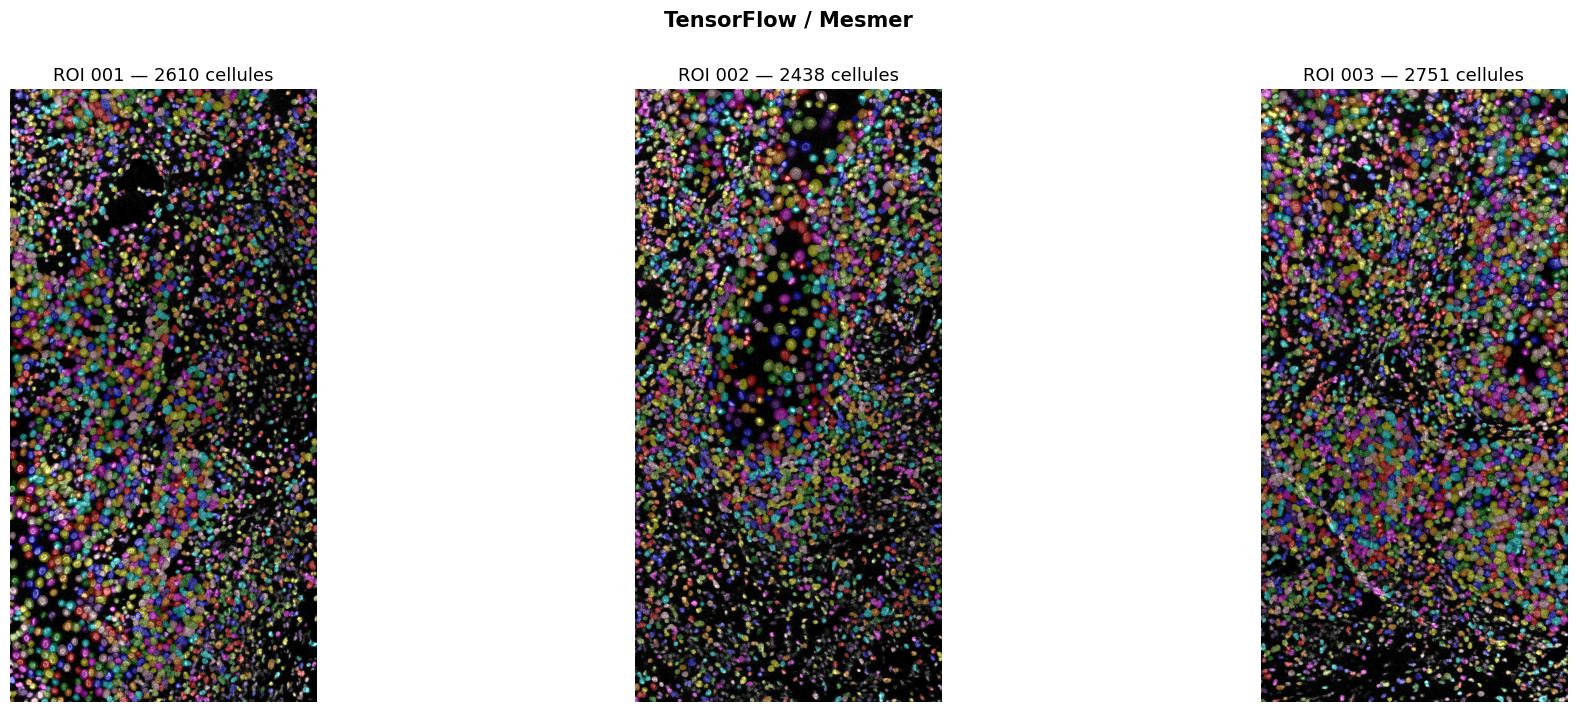

In [44]:
show_masks(MASKS_TF, "TensorFlow / Mesmer")

## Masks ONNX Runtime

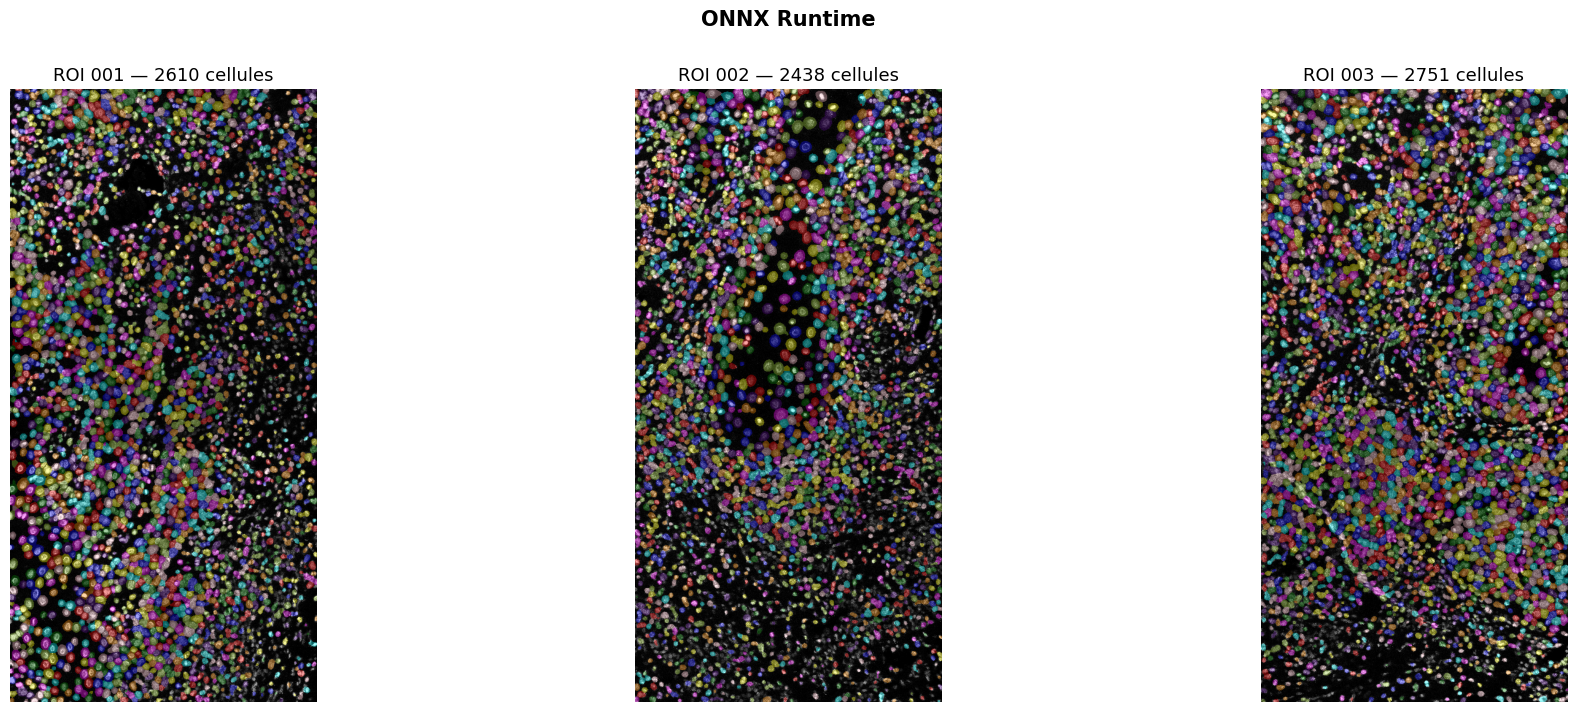

In [45]:
show_masks(MASKS_ONNX, "ONNX Runtime")

## Différence pixel-à-pixel

| Couleur | Signification |
|---|---|
| **Rouge** | TF uniquement |
| **Vert** | ONNX uniquement |
| **Blanc** | Les deux |
| **Noir** | Fond |

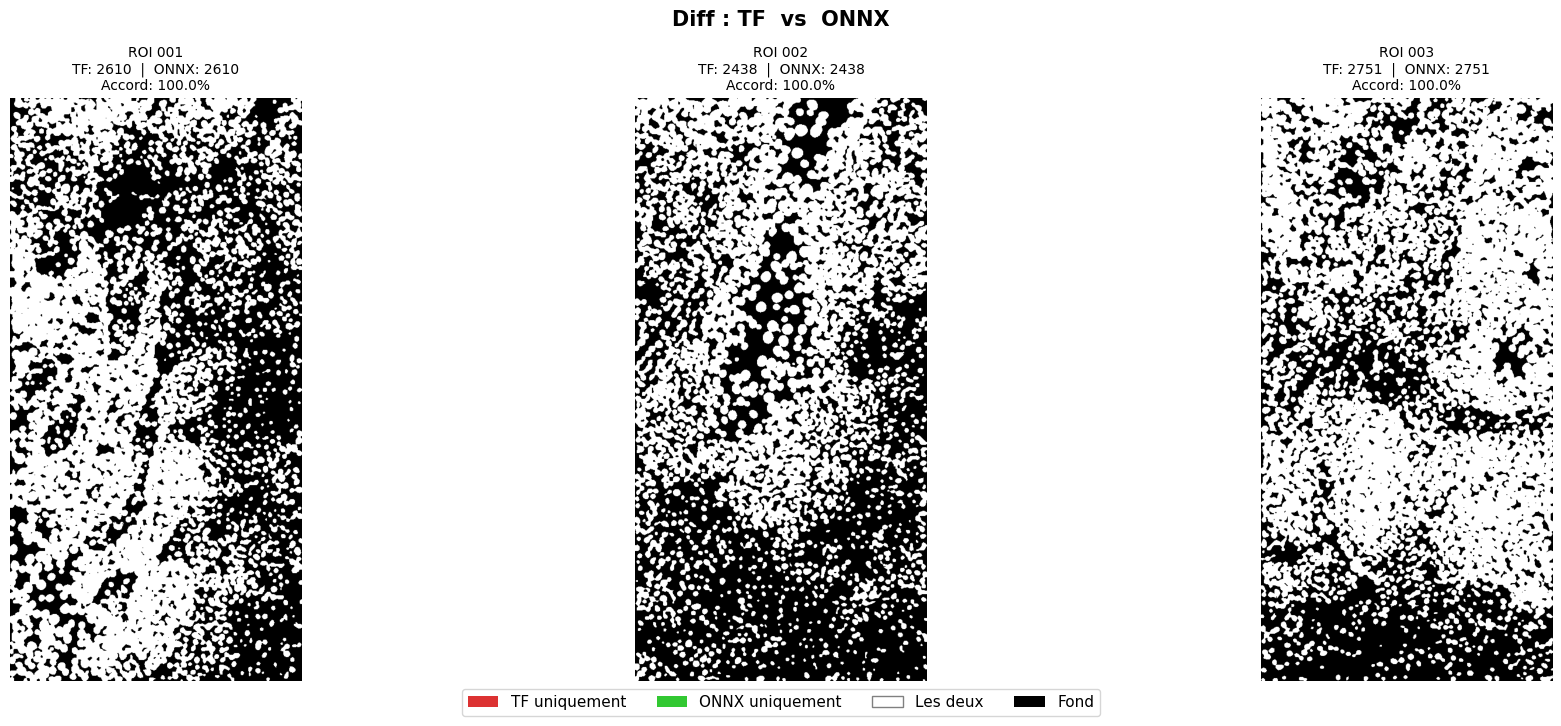

In [46]:
show_diff(MASKS_TF, "TF", MASKS_ONNX, "ONNX")